In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.utils.utils import find_project_root, load_ligand_models

BASE_DIR = find_project_root()

DATA_DIR = BASE_DIR / "data" / "processed" 

from figures.fig_scripts.fig3_functions import *
from src.analysis.GOAnalysis import GOAnalysis

/home/labs/antebilab/guyilan/master/rec_paper/data/external/go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms


### Load dataframes and results from R script:

In [4]:
go_sim_mat_json_form = json.load(open(DATA_DIR / "go_analysis" / 
                                      "go_jsons" / 
                                      "sim_results_kmeans_5_clusters_from_R.json", "r"))

#Generated in figure_2.ipynb
cluster_dict = json.load(open(DATA_DIR / "dicts" / "kmeans_5_clusters_dict.json", "r"))

In [5]:
models = load_ligand_models(subset=["BMP4"])
bmp4_model = models["BMP4"]

del models

### Process GO results for all clusters:

In [6]:
go_results_dict = load_go_dataframes_dict(
    path = DATA_DIR / "go_analysis" / "go_dataframes"
)

In [7]:
sig_terms_dict, _ = extract_significant_go_terms(go_results_dict)
go_id_name_dict, go_id_name_dict_reversed = extract_dictionaries(sig_terms_dict)
go_sim_mat_dict = create_go_sim_matrix(go_sim_mat_json_form, sig_terms_dict, go_id_name_dict)

Length of 4 before sim analysis: 137 and after: 123
Length of 5 before sim analysis: 167 and after: 149
Length of 3 before sim analysis: 40 and after: 35
Length of 1 before sim analysis: 14 and after: 14
Length of 2 before sim analysis: 165 and after: 158


In [8]:
goa_dict = {}

for cluster, df in go_results_dict.items():
    if go_sim_mat_dict.get(cluster).shape[0] < 2:
        continue
    print(f"Processing cluster {cluster}")
    goa = GOAnalysis(
        go_sim_mat_dict, go_results_dict, cluster_dict, cluster
    )
    goa_dict[cluster] = goa


Processing cluster 4
Initial number of GO terms: 123, after removing singletons: 26
Processing cluster 5
Initial number of GO terms: 149, after removing singletons: 33
Processing cluster 3
Initial number of GO terms: 35, after removing singletons: 10
Processing cluster 1
Initial number of GO terms: 14, after removing singletons: 10
Processing cluster 2
Initial number of GO terms: 158, after removing singletons: 28


### Split long term names from visualization:

In [9]:
goa_dict = prepare_go_terms_for_plotting(goa_dict)

### Generate Top10 GO terms plots for all clusters:

### Shared:

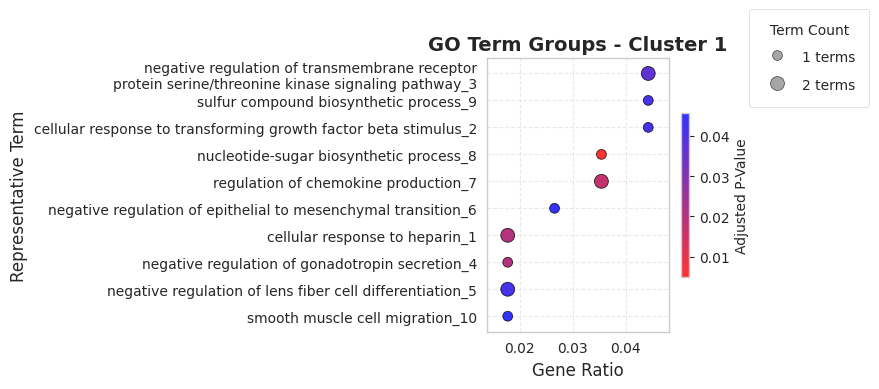

In [ ]:
plot_go_term_groups(goa_dict, "1", plotsize=(9, 4), save=False, top_n=10)

### Intermediate:

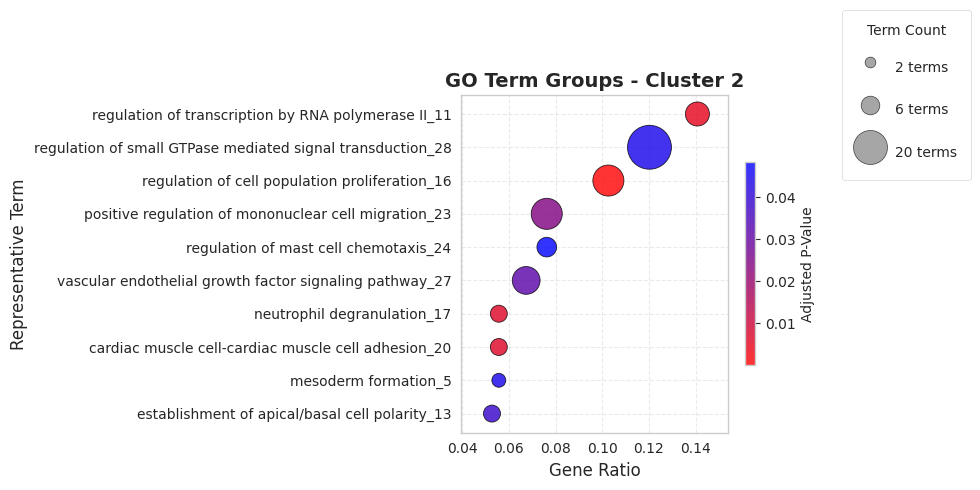

In [ ]:
plot_go_term_groups(goa_dict, "2", plotsize=(10, 5), save=False, top_n=10)

### Core BMP:

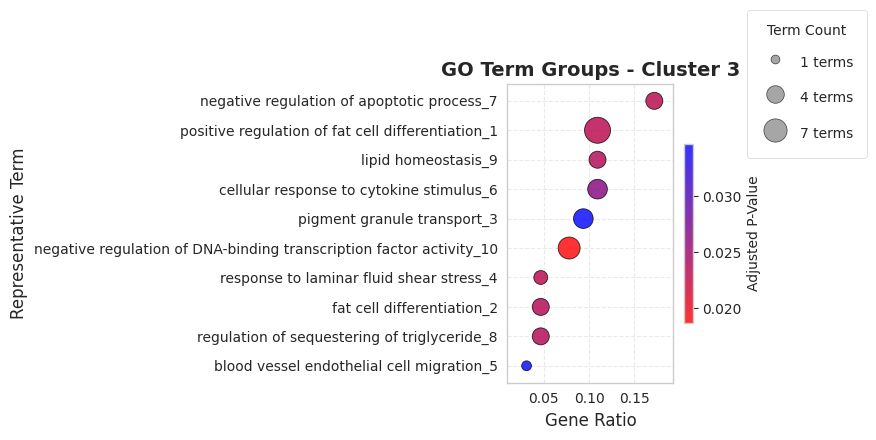

In [ ]:
plot_go_term_groups(goa_dict, "3", plotsize=(9, 4.5), save=False, top_n=10)

### TGFb1/BMP10:

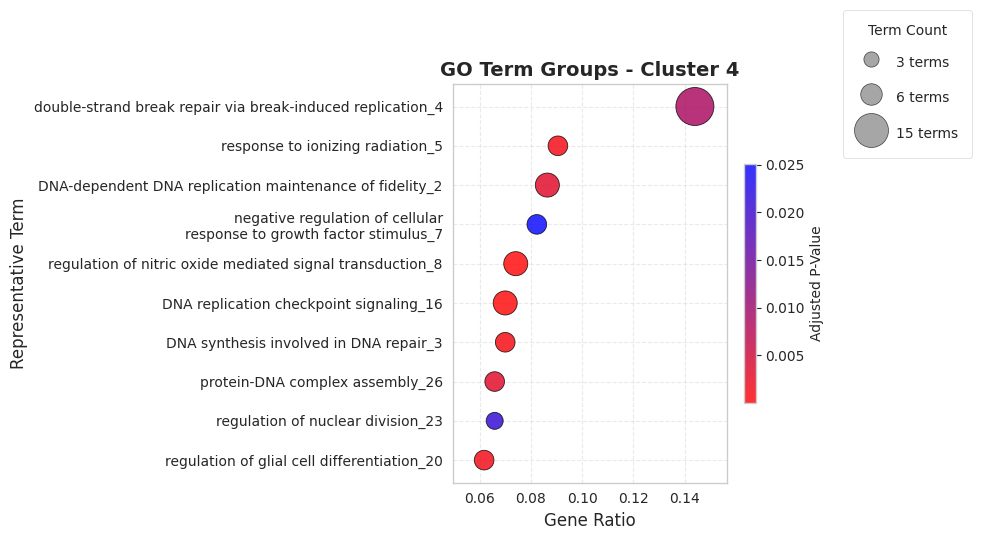

In [ ]:
plot_go_term_groups(goa_dict, "4", plotsize=(10, 5.5), save=False, top_n=10)

### GDF5:

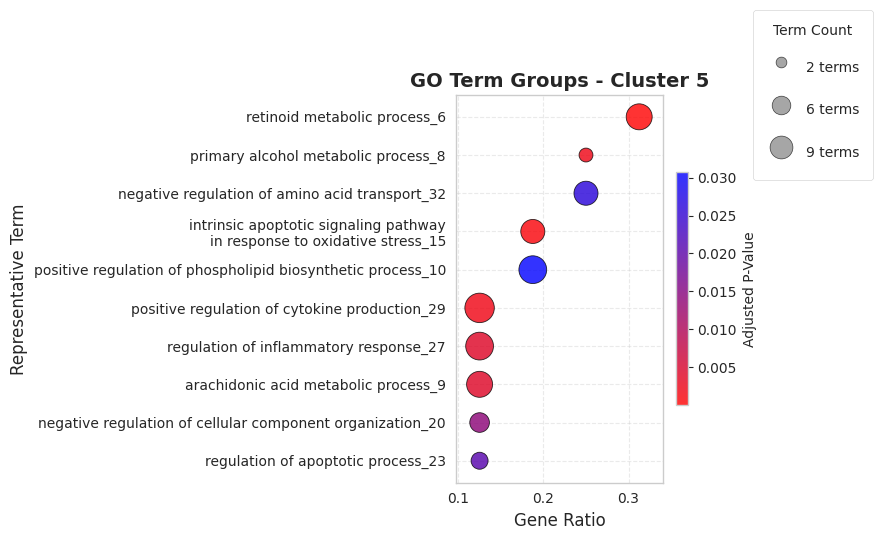

In [ ]:
plot_go_term_groups(goa_dict, "5", plotsize=(9, 5.5), save=False, top_n=10)

### Save summarized dataframes for all clusters:

In [22]:
os.makedirs(DATA_DIR / "grouped_dataframes", exist_ok=True)

# save each individual dataframe in go_sim_clusters_groups_dict to csv:
for k, obj in goa_dict.items():
    file_name = (
        DATA_DIR / f"grouped_dataframes/{k}_clusters_summary.csv"
    )
    if not os.path.exists(file_name):
        obj.go_sim_cluster_summary.to_csv(
            file_name,
            index=False,
        )
    else:
        print(f"File {file_name} already exists. Skipping save.")

# save the summary dictionary to csv files:
for k, obj in goa_dict.items():
    obj.go_sim_group_summary.sort_values(
        by=[
            "gene_ratio",
            "combined_score",
            "adjusted_p_value",
            "term_count",
            "term_depth",
        ],
        ascending=[False, False, True, False, False],
        inplace=True,
    )
    file_name = (
        DATA_DIR / f"grouped_dataframes/{k}_group_summary.csv"
    )
    if not os.path.exists(file_name):
        obj.go_sim_group_summary.to_csv(
            file_name,
            index=False,
        )
    else:
        print(f"File {file_name} already exists. Skipping save.")